# Wildfire Mitigation Simulation: Scenario and Intervention Design
## Defining the Intervention Timeline for Agent Simulation

**Creator:** Madeleine Melcher (madeleine_melcher@berkeley.edu)    
**Course:** INFO 290: Fundamentals of Generative AI (Spring 2026)  
**Instructor:** Cornelia Paulik

#### Citations
- Hou, A. B., Du, H., Wang, Y., Zhang, J., Wang, Z., Liang, P. P., Khashabi, D., Gardner, L., & He, T. (2025). *Can A Society of Generative Agents Simulate Human Behavior and Inform Public Health Policy?* arXiv:2503.09639
- Cornelia Paulik, INFO 290

#### Objectives

1. Define the event schema used by the simulation scheduler
2. Define intervention types grounded in wildfire mitigation policy and social experiences and map them to information channels
3. Build a baseline scenario YAML file that the simulation engine will leverage
4. Document the design rationale for intervention sequencing and targeting

#### Context

Our simulation engine (scheduler.py) loads intervention events from a YAML config.
Our simulation is intervention-driven: scheduled events like insurance notices, new regulations, and
wildfire experiences are the primary drivers of agent behavior. This approach is similar to research conducted by Hou et al. (2025), where  vaccine policy interventions were scheduled at defined timepoints, testing different policy configurations.

This notebook is a preliminary design of the content and structure of interventions for our simulation.


### Step 1: Setup

In [ ]:

# package installation
!pip install -U -q pyyaml matplotlib
import os

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 50.8 MB/s eta 0:00:00


In [ ]:
import yaml
from pathlib import Path

print("Imports complete!")

Imports complete!


### Step 2: Load existing agent config
 Inspecting the existing agent config to understand the attributes that our scenario needs to target before designing interventions.

In [ ]:
# information for jennifer, test case agent
# upload jennifer.yaml to /content/ in Colab before running; had issues mounting Google Drive

AGENT_CONFIG_PATH = Path('/content/jennifer.yaml')

with open(AGENT_CONFIG_PATH) as f:
    jennifer_config = yaml.safe_load(f)

print(f'Agent: {jennifer_config["name"]}')
print(f'Archetype: {jennifer_config["archetype"]}')
print(f'Compliance status: {jennifer_config["compliance_status"]}')
print(f'Insurance status: {jennifer_config["insurance_status"]}')

Agent: Jennifer
Archetype: The Resourceful DIYer
Compliance status: partial
Insurance status: retained


### Step 3: Define the event schema
Each intervention event needs a consistent structure that scheduler.py can parse and channels.py can frame. This is based on the schema established in the Stage 1 prototype, extending it for multi-agent scenarios.


Each event in our scenario has five fields: **day** (simulation day when the event occurs), **type** (event category, e.g., insurance_non_renewal), **channel** (how the agent receives it: official_mail, news_media, social, or direct_experience), **target_agents** (who receives it, or "all" for broadcast events), and **content** (the raw event text before channel-specific framing is applied). This schema is consistent with the Stage 1 prototype and designed to be consumed by scheduler.py and channels.py.

Our interventions will be drawn from real wildfire mitigation policy sources referenced in our project proposal:
CAL FIRE defensible space mandates (e.g., AB 3074, SB 504), insurance non-renewal trends from the California Department of Insurance, Firewise USA community outreach programs, Berkeley Ember ordinance documents, and/or direct wildfire experience.

Each intervention type maps to a specific information channel:

- **wildfire_news** (news_media): Major wildfire reported in a nearby region, covered in local news
- **defensible_space_law** (official_mail): New or updated defensible space regulation (e.g., AB 3074)
- **fire_service_doorknock** (social): Local fire department conducts door-to-door defensible space outreach
- **neighbor_clearing_brush** (social): Agent observes a neighbor actively doing vegetation management
- **insurance_non_renewal** (official_mail): Insurance company declines to renew policy due to wildfire risk
- **nearby_wildfire** (direct_experience): Wildfire burns within visible distance of the agent's property

### Step 4: Build the scenario timeline

This step defines the  scenario that will be exported as a YAML file for scheduler.py and stay constant across all variants.

The interventions escalate from low-urgency information (e.g., wildfire news in a nearby county) to high-urgency direct experience (e.g., wildfire visible from property). Events are spaced 7-14 days apart to allow agents with memory and reflection enabled to accumulate and process experiences between interventions.

Notes:
1) Event content is preliminary and will be refined as domain-specific policy research is integrated.
2) Duration and event spacing are configurable and may be adjusted based on experimental cost constraints.


In [ ]:
baseline_scenario = {
    'scenario_name': 'baseline',
    'description': 'Standard intervention sequence for ablation and model comparison experiments',
    'duration_days': 60,
    'events': [
        {
            'day': 1,
            'type': 'wildfire_news',
            'channel': 'news_media',
            'target_agents': 'all',
            'content': (
                'A fast-moving wildfire in Napa County has burned over 2,000 acres and '
                'destroyed 15 homes since Saturday. Cal Fire has deployed additional resources '
                'as dry winds are expected to continue through the week. Authorities are urging '
                'residents in high-risk areas throughout the Bay Area to review their defensible '
                'space and evacuation plans.'
            ),
        },
        {
            'day': 10,
            'type': 'defensible_space_law',
            'channel': 'official_mail',
            'target_agents': 'all',
            'content': (
                'Dear Resident, this letter is to inform you that under Assembly Bill 3074, '
                'the defensible space requirements for your property have been updated. You are '
                'now required to maintain a Zone 0 ember-resistant area within 0-5 feet of your '
                'structure, in addition to the existing Zone 1 and Zone 2 requirements. '
                'Compliance inspections will begin in your area within 90 days.'
            ),
        },
        {
            'day': 21,
            'type': 'fire_service_doorknock',
            'channel': 'social',
            'target_agents': 'Jennifer',
            'content': (
                'A uniformed fire prevention officer from the Berkeley Fire Department knocks '
                'on your door. They explain they are conducting defensible space assessments '
                'in the neighborhood as part of a Firewise USA community initiative. They offer '
                'to walk your property and point out areas where vegetation management could '
                'reduce your wildfire risk.'
            ),
        },
        {
            'day': 30,
            'type': 'neighbor_clearing_brush',
            'channel': 'social',
            'target_agents': 'Jennifer',
            'content': (
                'You notice your neighbor Tom spending the weekend clearing dead brush and '
                'trimming tree branches that overhang his roof. He mentions he hired a '
                'defensible space contractor after getting a notice from the fire department. '
                'He says the contractor quoted him $1,200 for the full property.'
            ),
        },
        {
            'day': 42,
            'type': 'insurance_non_renewal',
            'channel': 'official_mail',
            'target_agents': 'Jennifer',
            'content': (
                'Dear Policyholder, we regret to inform you that your homeowners insurance '
                'policy will not be renewed upon its expiration date of August 15, 2026. '
                'This decision is based on our assessment of elevated wildfire risk in your '
                'area. You may be eligible for coverage through the California FAIR Plan.'
            ),
        },
        {
            'day': 55,
            'type': 'nearby_wildfire',
            'channel': 'direct_experience',
            'target_agents': 'all',
            'content': (
                'A wildfire has broken out in the hills approximately 3 miles from your home. '
                'You can see a large smoke plume from your backyard and smell smoke in the air. '
                'Local authorities have issued an evacuation warning for your neighborhood. '
                'Emergency vehicles are passing frequently on the main road.'
            ),
        },
    ],
}

print(f'Scenario: {baseline_scenario["scenario_name"]}')
print(f'Duration: {baseline_scenario["duration_days"]} days')
print(f'Events: {len(baseline_scenario["events"])}\n')

print('Timeline:')
print('-' * 70)
for event in baseline_scenario['events']:
    print(f'  Day {event["day"]:3d}  |  {event["type"]:28s}  |  {event["channel"]:18s}  |  → {event["target_agents"]}')

Scenario: baseline
Duration: 60 days
Events: 6

Timeline:
----------------------------------------------------------------------
  Day   1  |  wildfire_news                 |  news_media          |  → all
  Day  10  |  defensible_space_law          |  official_mail       |  → all
  Day  21  |  fire_service_doorknock        |  social              |  → Jennifer
  Day  30  |  neighbor_clearing_brush       |  social              |  → Jennifer
  Day  42  |  insurance_non_renewal         |  official_mail       |  → Jennifer
  Day  55  |  nearby_wildfire               |  direct_experience   |  → all


### Step 5: Visualize the scenario timeline

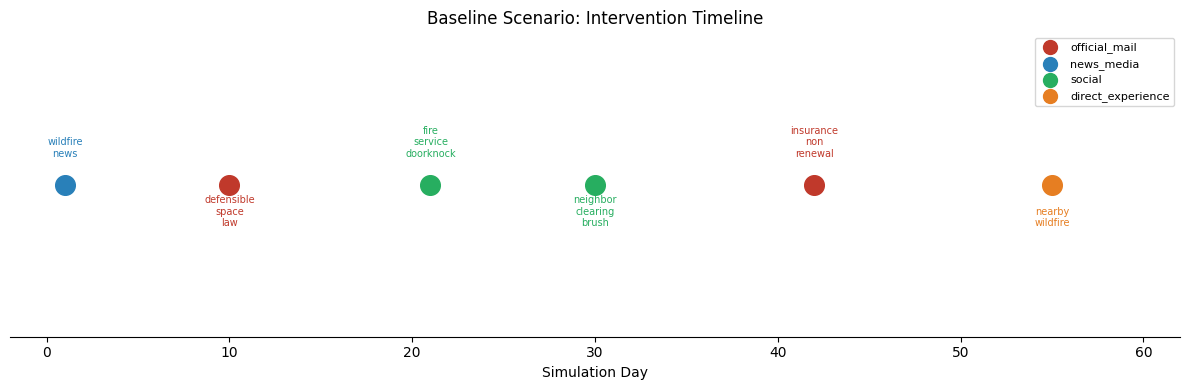

In [ ]:
import matplotlib.pyplot as plt

events = baseline_scenario['events']

channel_colors = {
    'official_mail': '#c0392b',
    'news_media': '#2980b9',
    'social': '#27ae60',
    'direct_experience': '#e67e22',
}

fig, ax = plt.subplots(figsize=(12, 4))

for i, event in enumerate(events):
    color = channel_colors[event['channel']]
    ax.scatter(event['day'], 0, s=200, c=color, zorder=3)
    ax.annotate(
        event['type'].replace('_', '\n'),
        (event['day'], 0),
        textcoords='offset points',
        xytext=(0, 20 if i % 2 == 0 else -30),
        ha='center',
        fontsize=7,
        color=color,
    )

for channel, color in channel_colors.items():
    ax.scatter([], [], c=color, s=100, label=channel)
ax.legend(loc='upper right', fontsize=8)

ax.set_xlim(-2, baseline_scenario['duration_days'] + 2)
ax.set_ylim(-1, 1)
ax.set_xlabel('Simulation Day')
ax.set_title('Baseline Scenario: Intervention Timeline')
ax.get_yaxis().set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

### Step 6: Export scenario as YAML
Writes the scenario to a YAML file that scheduler.py can leverage.

In [ ]:
output_path = Path('config/scenarios')
output_path.mkdir(parents=True, exist_ok=True)

yaml_path = output_path / 'baseline.yaml'

with open(yaml_path, 'w') as f:
    yaml.dump(baseline_scenario, f, default_flow_style=False, sort_keys=False)

print(f'Scenario written to {yaml_path}\n')

with open(yaml_path) as f:
    print(f.read())

Scenario written to config/scenarios/baseline.yaml

scenario_name: baseline
description: Standard intervention sequence for ablation and model comparison experiments
duration_days: 60
events:
- day: 1
  type: wildfire_news
  channel: news_media
  target_agents: all
  content: A fast-moving wildfire in Napa County has burned over 2,000 acres and destroyed
    15 homes since Saturday. Cal Fire has deployed additional resources as dry winds
    are expected to continue through the week. Authorities are urging residents in
    high-risk areas throughout the Bay Area to review their defensible space and evacuation
    plans.
- day: 10
  type: defensible_space_law
  channel: official_mail
  target_agents: all
  content: Dear Resident, this letter is to inform you that under Assembly Bill 3074,
    the defensible space requirements for your property have been updated. You are
    now required to maintain a Zone 0 ember-resistant area within 0-5 feet of your
    structure, in addition to the e

### Step 7: Design rationale and connection to experiments

The interventions escalate from low-urgency information (e.g., wildfire news in a nearby county) to high-urgency direct experience (e.g., wildfire visible from property). This mirrors how real homeowners often encounter wildfire risk, through a series of increasingly personal signals rather than a single event.

Events are spaced 7-14 days apart to allow agents with memory and reflection enabled (Experiment 1, Variant 1) to accumulate and synthesize experiences between interventions. This is where we expect the ablation study to show differences: agents without reflection (Variant 2) will have raw memories but no synthesized beliefs, and agents without memory (Variant 3) will respond to each event in isolation.

This scenario YAML is held constant across all variants in both experiments. Only the system architecture or model configuration changes. The interventions, their timing, their channels, and their content will stay the same. This will allow us to attribute differences in agent behavior to the system variant rather than the input.

**Limitations:**
- Currently only one agent (Jennifer) is fully configured. Target agents will be updated as additional agent configs are created.
- Event content is preliminary and will be refined as domain-specific policy research is integrated.
- Duration and event spacing are configurable and may be adjusted based on experimental cost constraints.